<div style="width:image width px; font-size:75%; text-align:right;">
    <img src="https://watcher.guru/news/wp-content/uploads/2023/10/bitcoin-ethereum-800x450.jpeg.webp" width="width" height="height" style="padding-bottom:0.2em;" />
    <figcaption>Quelle: https://watcher.guru/news/bitcoin-ethereum-have-15b-worth-of-options-that-expire-today</figcaption>
</div>

# Modellierung der Preisvorhersage der Kryptowährungen Bitcoin und Ethereum. Wie wird der Ethereum Preisverlauf durch Bitcoin beeinflusst?


## **Gliederung**

1. **Beschreibung und Bearbeitung der Datensätze**
2. **Erörterung des Bitcoin-Datensatzes**
3. **Erörterung des Ethereum-Datensatzes**
4. **Preisprognosen von Bitcoin und Ethereum**
5. **Untersuchung des Einflusses von Bitcoin auf Ethereum**
6. **Fazit**


## **Notwendige Importe**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import grangercausalitytests

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

### **Datensätze**

**Bitcoin:** \
Quelle des Datensatzes: https://de.finance.yahoo.com/quote/BTC-USD/history \
Bitcoin Kurseinträge von 17.09.2014 bis 01.05.2024


**Ethereum:** \
Quelle des Datensatzes: https://de.finance.yahoo.com/quote/ETH-USD/history \
Ethereum Kurseinträge von 09.11.2017 bis 01.05.2024


**Beide Datensätze enthalten folgende Spalten:** \
Date = Kurstag \
Open = Eröffnungspreis am Kurstag\
High = Tages-Hoch am Kurstag\
Low = Tages-Tief am Kurstag\
Close = Schlusskurs am Kurstag\
Adjusted Close = Angepasster Schlusskurs am Kurstag\
Volume = Handelsvolumen am Tag

Es ist zu beachten, dass es für Bitcoin und Ethereum keine festgelegten Handelszeiten und ebenfalls keine (angepassten) Schlusskurse gibt.

In [2]:
# Einlesen der Datensätze
df_btc = pd.read_csv("BTC-USD.csv")
df_eth = pd.read_csv("ETH-USD.csv")

In [3]:
print(df_btc.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3515 entries, 0 to 3514
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       3515 non-null   object 
 1   Open       3515 non-null   float64
 2   High       3515 non-null   float64
 3   Low        3515 non-null   float64
 4   Close      3515 non-null   float64
 5   Adj Close  3515 non-null   float64
 6   Volume     3515 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 192.4+ KB
None


### **Bitcoin Datensatz enthält keine NULL-Werte**

In [4]:
df_btc.isna()

,Date,Open,High,Low,Close,Adj Close,Volume
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
3510,False,False,False,False,False,False,False
3511,False,False,False,False,False,False,False
3512,False,False,False,False,False,False,False
3513,False,False,False,False,False,False,False


In [5]:
print(df_btc)

            Date          Open          High           Low         Close  \
0     2014-09-17    465.864014    468.174011    452.421997    457.334015   
1     2014-09-18    456.859985    456.859985    413.104004    424.440002   
2     2014-09-19    424.102997    427.834991    384.532013    394.795990   
3     2014-09-20    394.673004    423.295990    389.882996    408.903992   
4     2014-09-21    408.084991    412.425995    393.181000    398.821014   
...          ...           ...           ...           ...           ...   
3510  2024-04-27  63750.988281  63898.363281  62424.718750  63419.140625   
3511  2024-04-28  63423.515625  64321.484375  62793.597656  63113.230469   
3512  2024-04-29  63106.363281  64174.878906  61795.457031  63841.121094   
3513  2024-04-30  63839.417969  64703.332031  59120.066406  60636.855469   
3514  2024-05-01  60609.496094  60780.500000  56555.292969  58254.011719   

         Adj Close       Volume  
0       457.334015     21056800  
1       424.440002 

In [6]:
print(df_eth.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2366 entries, 0 to 2365
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2366 non-null   object 
 1   Open       2366 non-null   float64
 2   High       2366 non-null   float64
 3   Low        2366 non-null   float64
 4   Close      2366 non-null   float64
 5   Adj Close  2366 non-null   float64
 6   Volume     2366 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 129.5+ KB
None


### **Datensatz enthält keine NULL-Werte**

In [7]:
df_btc.isna()

,Date,Open,High,Low,Close,Adj Close,Volume
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
3510,False,False,False,False,False,False,False
3511,False,False,False,False,False,False,False
3512,False,False,False,False,False,False,False
3513,False,False,False,False,False,False,False


In [8]:
print(df_eth)

            Date         Open         High          Low        Close  \
0     2017-11-09   308.644989   329.451996   307.056000   320.884003   
1     2017-11-10   320.670990   324.717987   294.541992   299.252991   
2     2017-11-11   298.585999   319.453003   298.191986   314.681000   
3     2017-11-12   314.690002   319.153015   298.513000   307.907990   
4     2017-11-13   307.024994   328.415009   307.024994   316.716003   
...          ...          ...          ...          ...          ...   
2361  2024-04-27  3129.727051  3279.451172  3071.340088  3252.168213   
2362  2024-04-28  3252.245605  3351.176514  3249.149170  3262.774658   
2363  2024-04-29  3262.340820  3285.468750  3116.199951  3215.428955   
2364  2024-04-30  3215.381104  3249.378418  2918.228760  3012.286865   
2365  2024-05-01  3011.015625  3020.173340  2815.923340  2969.784668   

        Adj Close       Volume  
0      320.884003    893249984  
1      299.252991    885985984  
2      314.681000    842300992  
3  

### **Notwendige Schritte vor der Verarbeitung der Daten**

* Umwandlung der 'Date'-Spalte in das Datetime-Format: Dies ermöglicht Daten als Zeitreihen zu behandeln. Mit dem Format 'datetime' ist die Nutzung spezieller Pandas-Funktionen (Resampling etc.) möglich.
* Umwandlung von relevanten Spalten in nummerische Werte als Voraussetzung für mathematische Operationen
* Festlegung des Datums als Index. Dies vereinfacht die Abfrage und Manipulation der vorliegenden Daten. Hilfreich bei der Visualisierung der Daten.

In [9]:
# Umwandlung der 'Date'-Spalte in das Datetime-Format
df_btc['Date'] = pd.to_datetime(df_btc['Date'])
df_eth['Date'] = pd.to_datetime(df_eth['Date'])

# Sicherstellen, dass alle relevanten Spalten numerisch sind
numeric_columns = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
df_btc[numeric_columns] = df_btc[numeric_columns].apply(pd.to_numeric, errors='coerce')
df_eth[numeric_columns] = df_eth[numeric_columns].apply(pd.to_numeric, errors='coerce')

# Setzen des Datums als Index
df_btc.set_index('Date', inplace=True)
df_eth.set_index('Date', inplace=True)

## **Bitcoin Preisverlauf**

* Diagramm mit dem Bitcoin Preisverlauf von 17.09.2014 bis 01.05.2024. Die letzten zwei All Time Highs waren in den Jahren 2021 und 2024.
* Für die Darstellung des Bitcoin Preisverlaufs wurde die Spalte "High" (täglich aggregiert) verwendet.

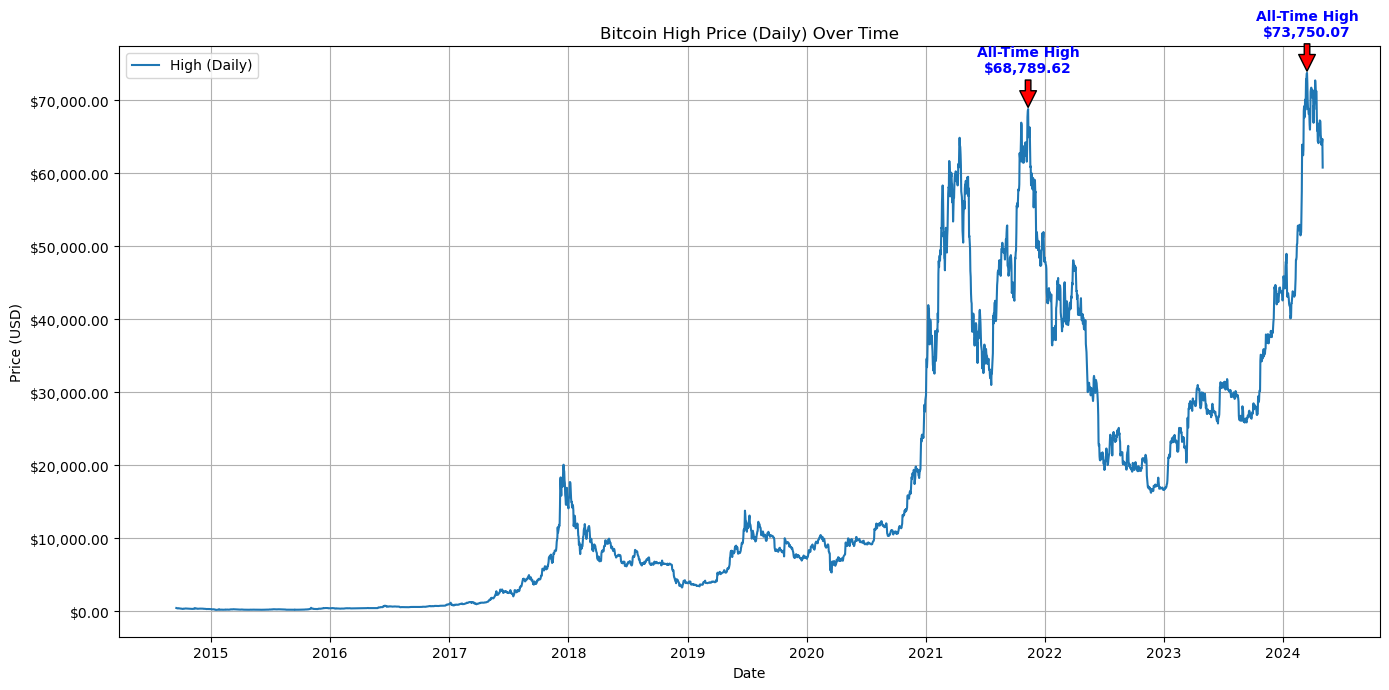

In [10]:
# Funktion zur Erstellung des täglich aggregierten Diagramms mit Markierung der All-Time Highs
def plot_aggregated_daily_with_ATH(df, column, title):
    # Resampling der Daten auf tägliche Mittelwerte (in diesem Fall direkt die angegebene Spalte verwenden)
    df_resampled = df[column]
    
    # Ermitteln der All-Time Highs für 2021 und 2024
    ath_2021 = df_resampled['2021'].max()
    ath_2021_date = df_resampled['2021'].idxmax()
    ath_2024 = df_resampled['2024'].max()
    ath_2024_date = df_resampled['2024'].idxmax()
    
    # Erstellen des Diagramms
    plt.figure(figsize=(14, 7))
    plt.plot(df_resampled.index, df_resampled, label=f'{column} (Daily)')
    
    # Markierung der All-Time Highs mit Preisangabe
    plt.annotate(f'All-Time High\n${ath_2021:,.2f}', xy=(ath_2021_date, ath_2021), xytext=(ath_2021_date, ath_2021 + 5000),
                 arrowprops=dict(facecolor='red', shrink=0.05),
                 horizontalalignment='center',
                 fontsize=10, color='blue', fontweight='bold')
    
    plt.annotate(f'All-Time High\n${ath_2024:,.2f}', xy=(ath_2024_date, ath_2024), xytext=(ath_2024_date, ath_2024 + 5000),
                 arrowprops=dict(facecolor='red', shrink=0.05),
                 horizontalalignment='center',
                 fontsize=10, color='blue', fontweight='bold')
    
    # Achsenbeschriftungen und Titel
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.title(title)
    plt.legend()
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'${x:,.2f}'))
    plt.grid(True)
    plt.tight_layout()
    plt.show()


plot_aggregated_daily_with_ATH(df_btc, 'High', 'Bitcoin High Price (Daily) Over Time')


## **Bitcoin Handelsvolumen**

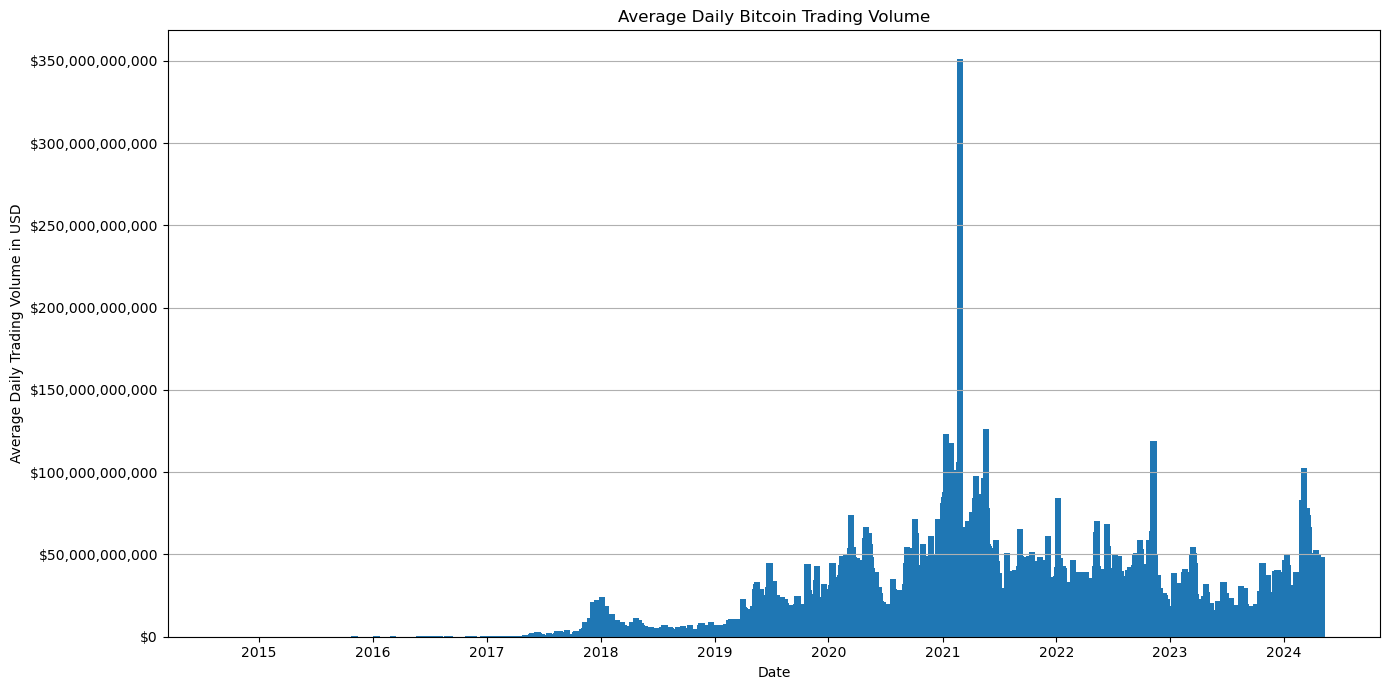

In [11]:
# Funktion zur Erstellung des täglich durchschnittlich aggregierten Handelsvolumens über die Zeit
def plot_avg_volume_daily(df, title):
    df_resampled = df['Volume'].resample('D').mean()  
    plt.figure(figsize=(14, 7))
    plt.bar(df_resampled.index, df_resampled, width=20, align='center')
    plt.xlabel('Date')
    plt.ylabel('Average Daily Trading Volume in USD')
    plt.title(title)
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'${x:,.0f}'))
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()


plot_avg_volume_daily(df_btc, 'Average Daily Bitcoin Trading Volume')


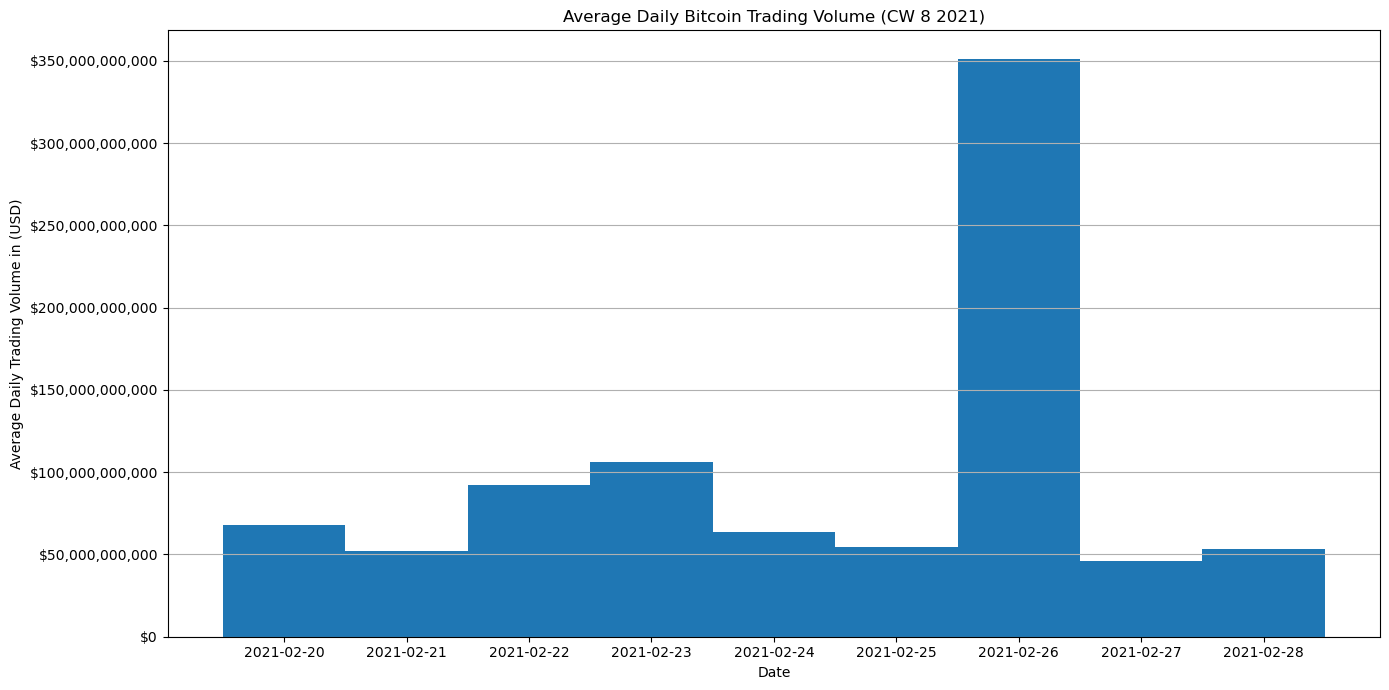

In [12]:
# Erstellen des täglich durchschnittlich aggregierten Handelsvolumens über die Zeit
def plot_avg_volume_daily(df, title):
    # Filterung der Daten für den Zeitraum von 2020 bis 2022
    df_filtered = df.loc['2021-02-20':'2021-02-28']
    
    # Berechnen des täglich aggregegierten Durchschnitts des Volumens
    df_resampled = df_filtered['Volume'].resample('D').mean()
    
    # Erstellen des Diagramms
    plt.figure(figsize=(14, 7))
    plt.bar(df_resampled.index, df_resampled, width=1, align='center')
    plt.xlabel('Date')
    plt.ylabel('Average Daily Trading Volume in (USD)')
    plt.title(title)
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'${x:,.0f}'))
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()


plot_avg_volume_daily(df_btc, 'Average Daily Bitcoin Trading Volume (CW 8 2021)')


## **Täglich aggregierte High-Preise und gleitende Durchschnitte (Moving Averages)**

Gleitende Durchschnitte bilden einen beliebten Indikator, um einen Trend oder dessen Veränderung zu erkennen und gleichzeitig extreme Schwankungen in den Märkten zu glätten.

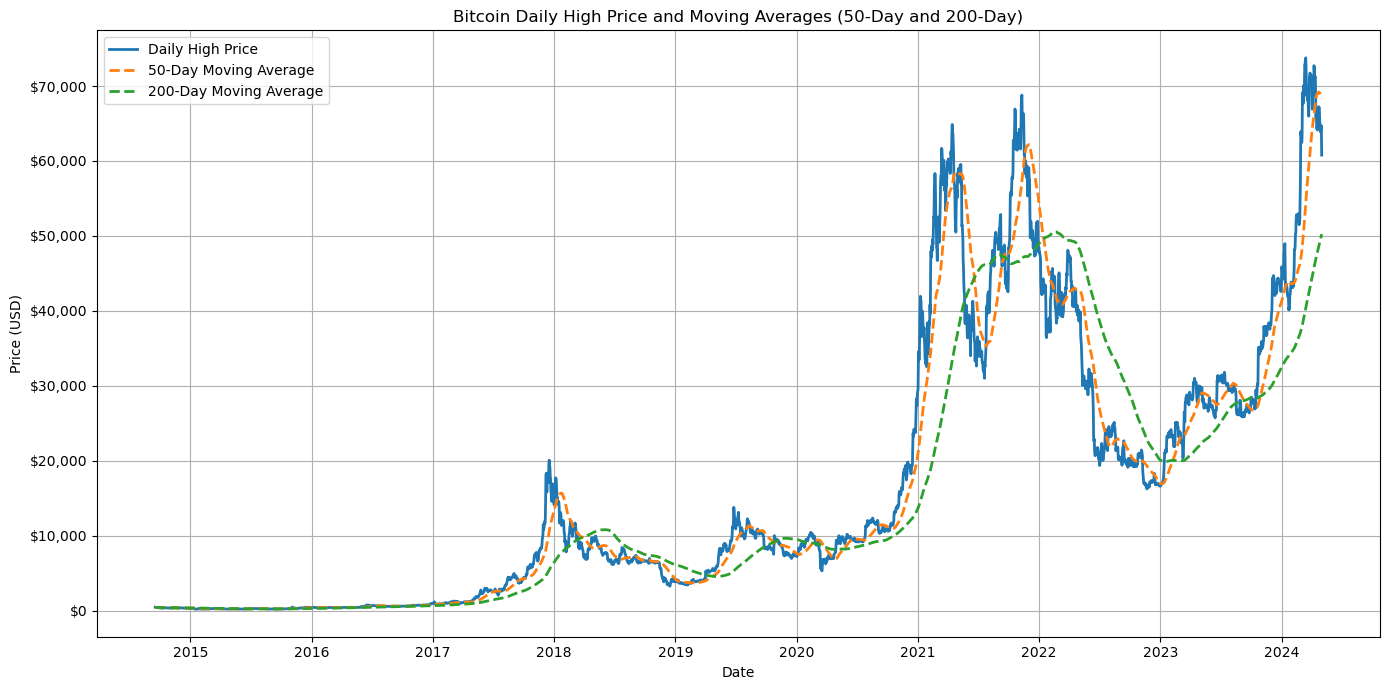

In [13]:
# Funktion zur Erstellung der täglich aggregierten High-Preise und gleitender Durchschnitte
def plot_daily_high_moving_averages(df, title):
    df_resampled = df['High'].resample('D').mean()
    ma_50 = df_resampled.rolling(window=50, min_periods=1).mean()
    ma_200 = df_resampled.rolling(window=200, min_periods=1).mean()
    
    plt.figure(figsize=(14, 7))
    plt.plot(df_resampled.index, df_resampled, label='Daily High Price', linewidth=2)
    plt.plot(df_resampled.index, ma_50, label='50-Day Moving Average', linestyle='--', linewidth=2)
    plt.plot(df_resampled.index, ma_200, label='200-Day Moving Average', linestyle='--', linewidth=2)
    
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.title(title)
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'${x:,.0f}'))
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


plot_daily_high_moving_averages(df_btc, 'Bitcoin Daily High Price and Moving Averages (50-Day and 200-Day)')


## **Mögliche Korrelation zwischen dem Bitcoin Preisverlauf und Handelsvolumen**

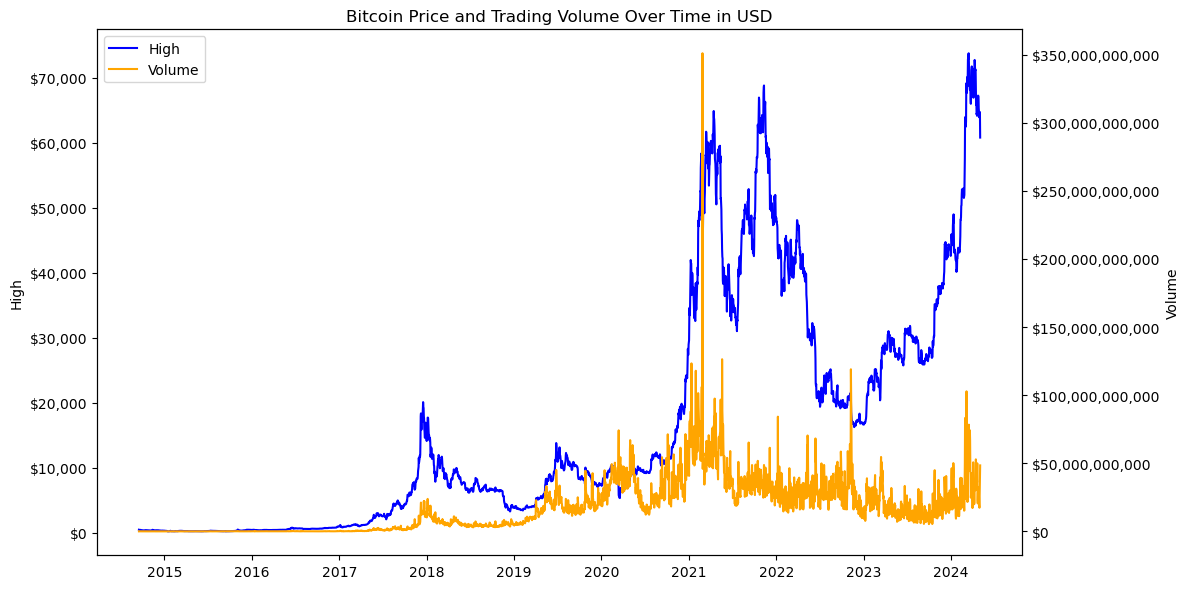

In [14]:
# Plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primäre y-Achse (High)
line1, = ax1.plot(df_btc.index, df_btc['High'], color='blue', label='High')
ax1.set_ylabel('High')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'${x:,.0f}'))
ax1.tick_params(axis='y')

# Sekundäre y-Achse (Volume)
ax2 = ax1.twinx()
line2, = ax2.plot(df_btc.index, df_btc['Volume'], color='orange', label='Volume')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'${x:,.0f}'))
ax2.set_ylabel('Volume')
ax2.tick_params(axis='y')

# Titel und Beschriftungen
plt.title('Bitcoin Price and Trading Volume Over Time in USD')
plt.xlabel('Date')

# Kombinierung der Legenden
lines = [line1, line2]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper left')

fig.tight_layout()  
plt.show()

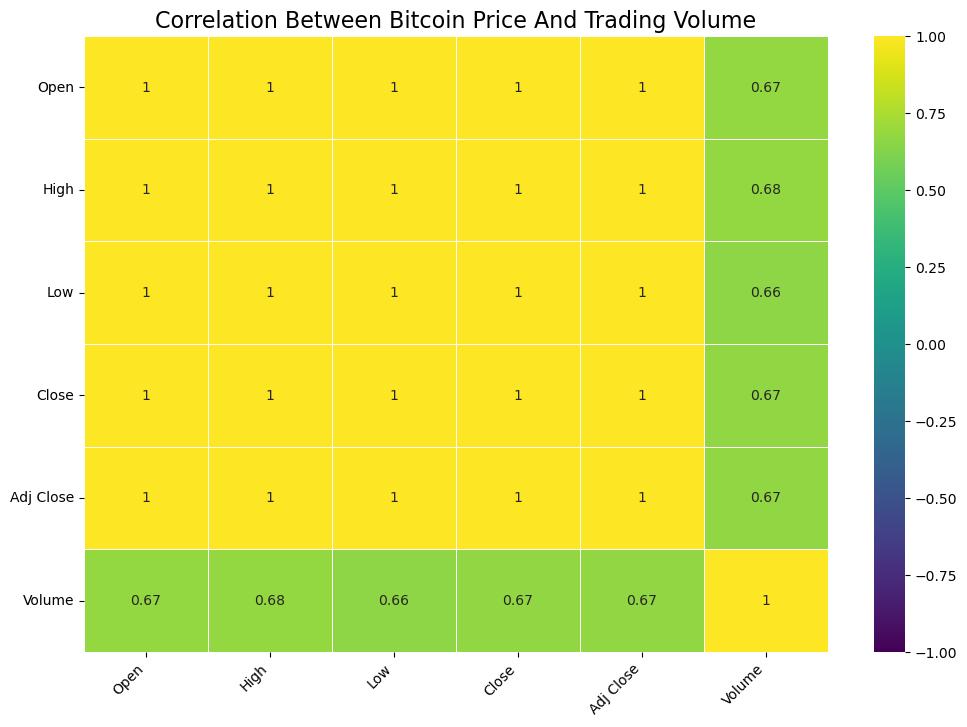

In [15]:
# Berechnung der Korrelation zwischen den Spalten
correlation_matrix = df_btc[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']].corr()

# Plot der Korrelationen
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', vmin=-1, vmax=1, linewidths=0.5, linecolor='white')
plt.title('Correlation Between Bitcoin Price And Trading Volume', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

## Ethereum Preisverlauf

* Diagramm mit dem Ethereum Preisverlauf von 09.11.2017 bis 01.05.2024. Das letzte All Time High war im Jahr 2021.
* Für die Darstellung des Ethereum Preisverlaufs wurde die Spalte "High" (täglich aggregiert) verwendet.

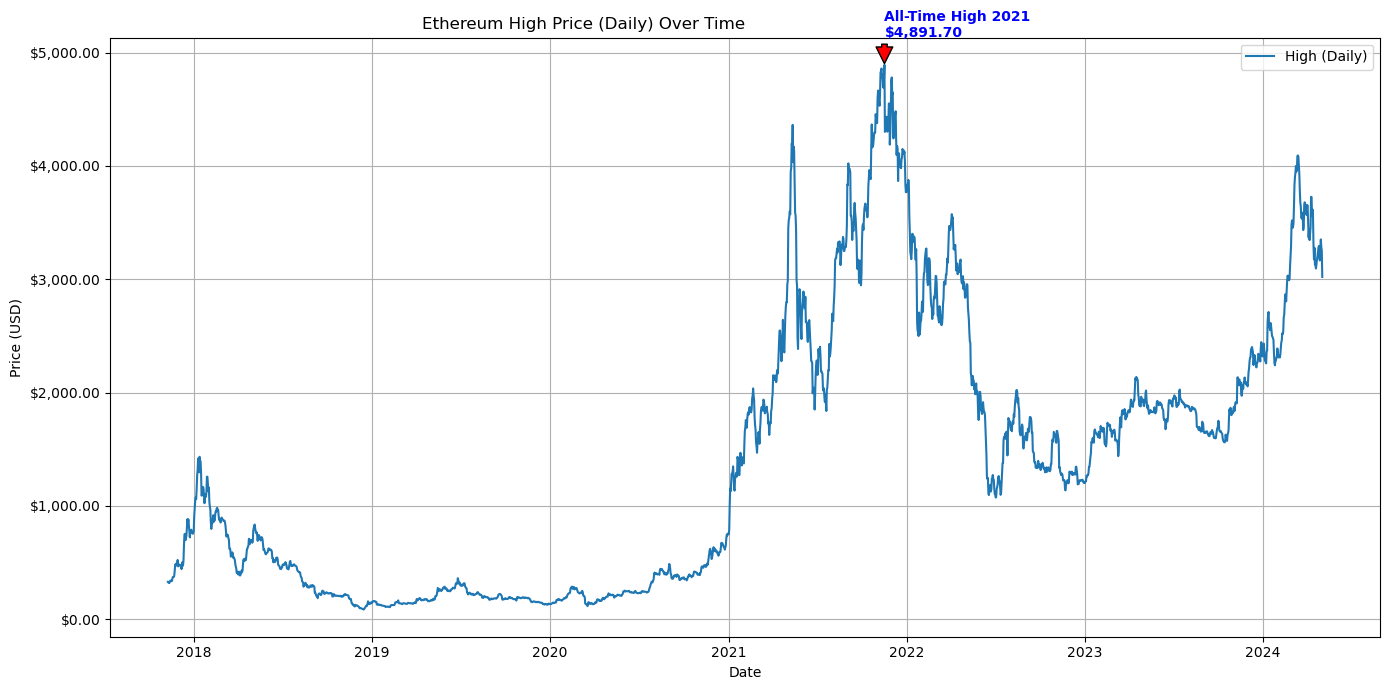

In [16]:
# Funktion zur Erstellung des täglich aggregierten Diagramms mit Markierung der All-Time Highs
def plot_aggregated_daily_with_ATH(df, column, title):
    # Resampling der Daten auf tägliche Mittelwerte
    df_resampled = df[column].resample('D').mean()

    # All-Time Highs für 2021 ermitteln
    ath_2021 = df_resampled['2021'].max()
    ath_2021_date = df_resampled['2021'].idxmax()

    # Erstellen des Diagramms
    plt.figure(figsize=(14, 7))
    plt.plot(df_resampled.index, df_resampled, label=f'{column} (Daily)')

    # Markierung der All-Time Highs mit Preisangabe
    plt.annotate(f'All-Time High 2021\n${ath_2021:,.2f}', 
                 xy=(ath_2021_date, ath_2021), 
                 xytext=(ath_2021_date, ath_2021 + ath_2021 * 0.05),
                 arrowprops=dict(facecolor='red', shrink=0.05),
                 horizontalalignment='left',
                 fontsize=10, color='blue', fontweight='bold')

    # Achsenbeschriftungen und Titel
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.title(title, horizontalalignment='right')
    plt.legend()
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'${x:,.2f}'))
    plt.grid(True)
    plt.tight_layout()
    plt.show()


plot_aggregated_daily_with_ATH(df_eth, 'High', 'Ethereum High Price (Daily) Over Time')

## **Ethereum Handelsvolumen**

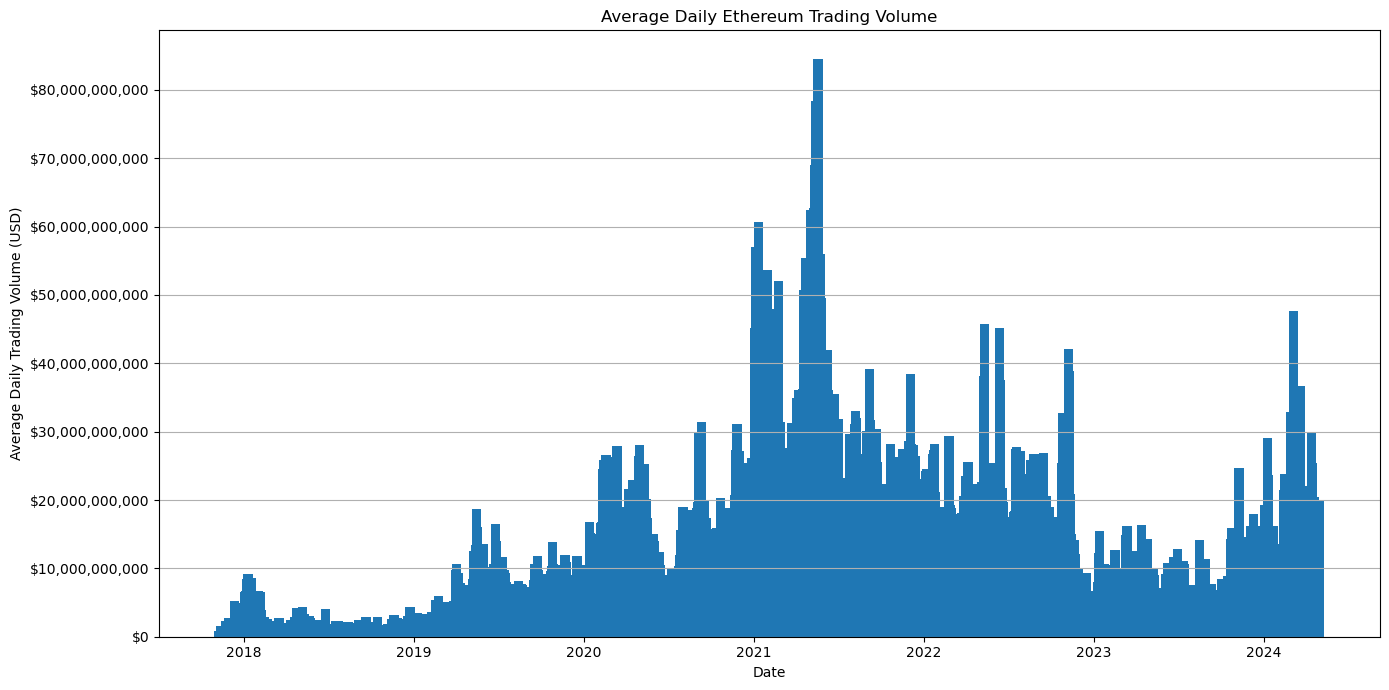

In [17]:
# Funktion zur Erstellung des täglich durchschnittlich aggregierten Handelsvolumens über die Zeit
def plot_avg_volume_daily(df, title):
    df_resampled = df['Volume'].resample('D').mean()
    plt.figure(figsize=(14, 7))
    plt.bar(df_resampled.index, df_resampled, width=20, align='center')
    plt.xlabel('Date')
    plt.ylabel('Average Daily Trading Volume (USD)')
    plt.title(title)
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'${x:,.0f}'))
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()

plot_avg_volume_daily(df_eth, 'Average Daily Ethereum Trading Volume')

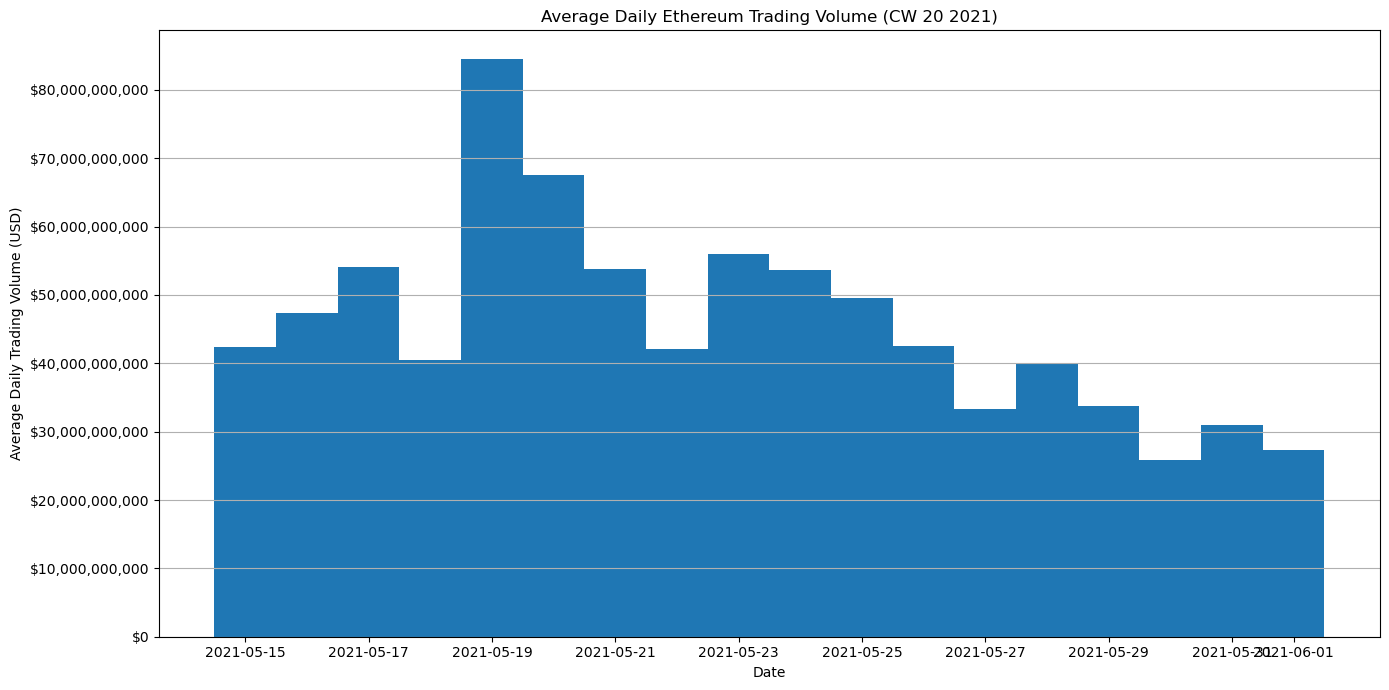

In [18]:
# Funktion zur Erstellung des täglich durchschnittlich aggregierten Handelsvolumens über die Zeit
def plot_avg_volume_daily(df, title):
    # Filterung der Daten für den Zeitraum von 2020 bis 2022
    df_filtered = df.loc['2021-05-15':'2021-06-01']
    
    # Ermittlung des Durchschnitts des Volumens
    df_resampled = df_filtered['Volume'].resample('D').mean()
    
    # Erstellen des Diagramms
    plt.figure(figsize=(14, 7))
    plt.bar(df_resampled.index, df_resampled, width=1, align='center')
    plt.xlabel('Date')
    plt.ylabel('Average Daily Trading Volume (USD)')
    plt.title(title)
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'${x:,.0f}'))
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()

plot_avg_volume_daily(df_eth, 'Average Daily Ethereum Trading Volume (CW 20 2021)')

## **Täglich aggregierte High-Preise und gleitende Durchschnitte (Moving Averages)**

Gleitende Durchschnitte bilden einen beliebten Indikator, um einen Trend oder dessen Veränderung zu erkennen und gleichzeitig extreme Schwankungen in den Märkten zu glätten.

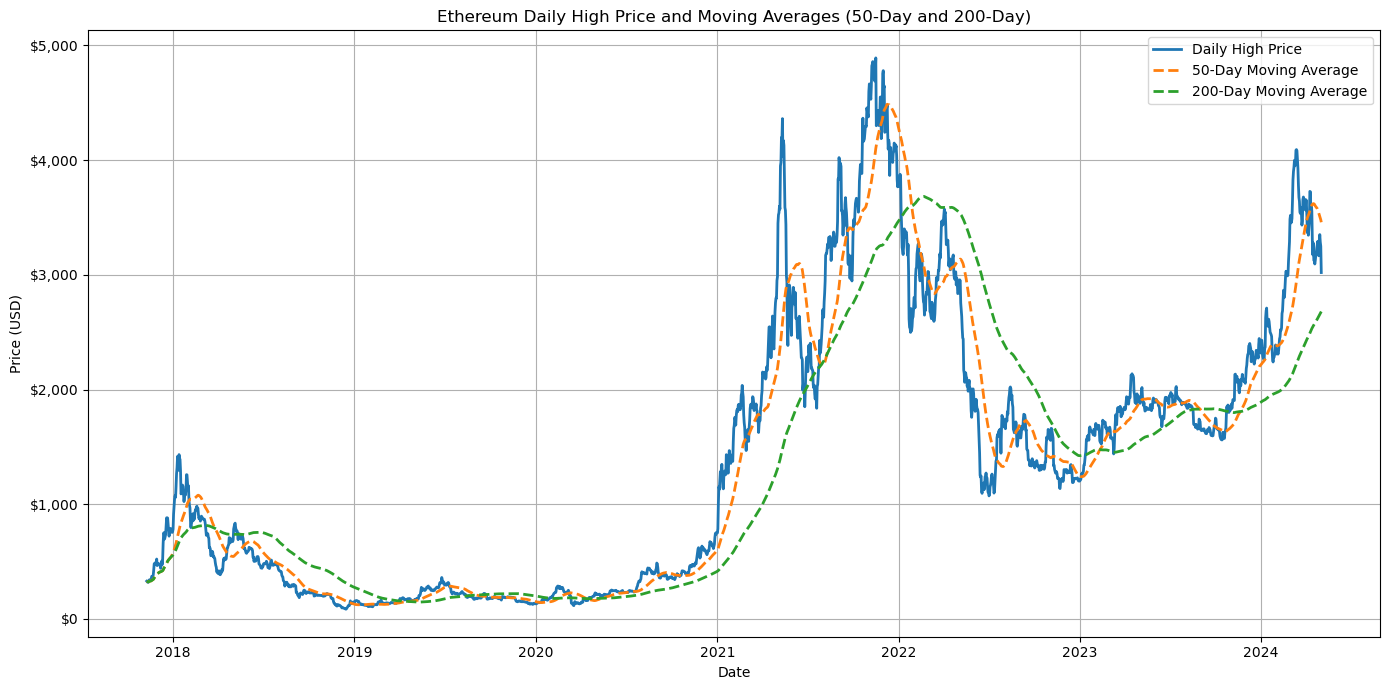

In [19]:
# Funktion zur Erstellung der täglich aggregierten High-Preise und gleitender Durchschnitte
def plot_daily_high_moving_averages(df, title):
    df_resampled = df['High'].resample('D').mean()  # Täglich aggregierte High-Preise
    ma_50 = df_resampled.rolling(window=50, min_periods=1).mean()  # 50-Tage gleitender Durchschnitt
    ma_200 = df_resampled.rolling(window=200, min_periods=1).mean()  # 200-Tage gleitender Durchschnitt
    
    plt.figure(figsize=(14, 7))
    plt.plot(df_resampled.index, df_resampled, label='Daily High Price', linewidth=2)
    plt.plot(df_resampled.index, ma_50, label='50-Day Moving Average', linestyle='--', linewidth=2)
    plt.plot(df_resampled.index, ma_200, label='200-Day Moving Average', linestyle='--', linewidth=2)
    
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.title(title)
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'${x:,.0f}'))
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_daily_high_moving_averages(df_eth, 'Ethereum Daily High Price and Moving Averages (50-Day and 200-Day)')

## **Mögliche Korrelation zwischen dem Ethereum Preisverlauf und dem Handelsvolumen**

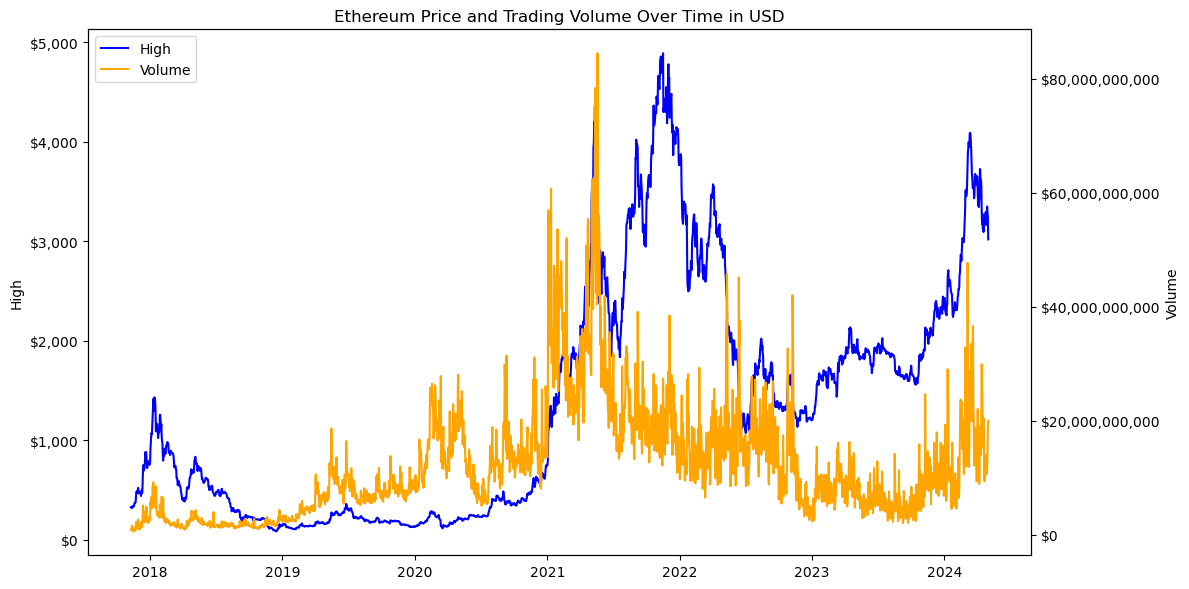

In [20]:
# Plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primäre y-Achse (High)
line1, = ax1.plot(df_eth.index, df_eth['High'], color='blue', label='High')
ax1.set_ylabel('High')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'${x:,.0f}'))
ax1.tick_params(axis='y')

# Sekundäre y-Achse (Volume)
ax2 = ax1.twinx()
line2, = ax2.plot(df_eth.index, df_eth['Volume'], color='orange', label='Volume')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'${x:,.0f}'))
ax2.set_ylabel('Volume')
ax2.tick_params(axis='y')

# Titel und Beschriftungen
plt.title('Ethereum Price and Trading Volume Over Time in USD')
plt.xlabel('Date')

# Kombinierung der Legenden
lines = [line1, line2]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper left')

fig.tight_layout()  
plt.show()

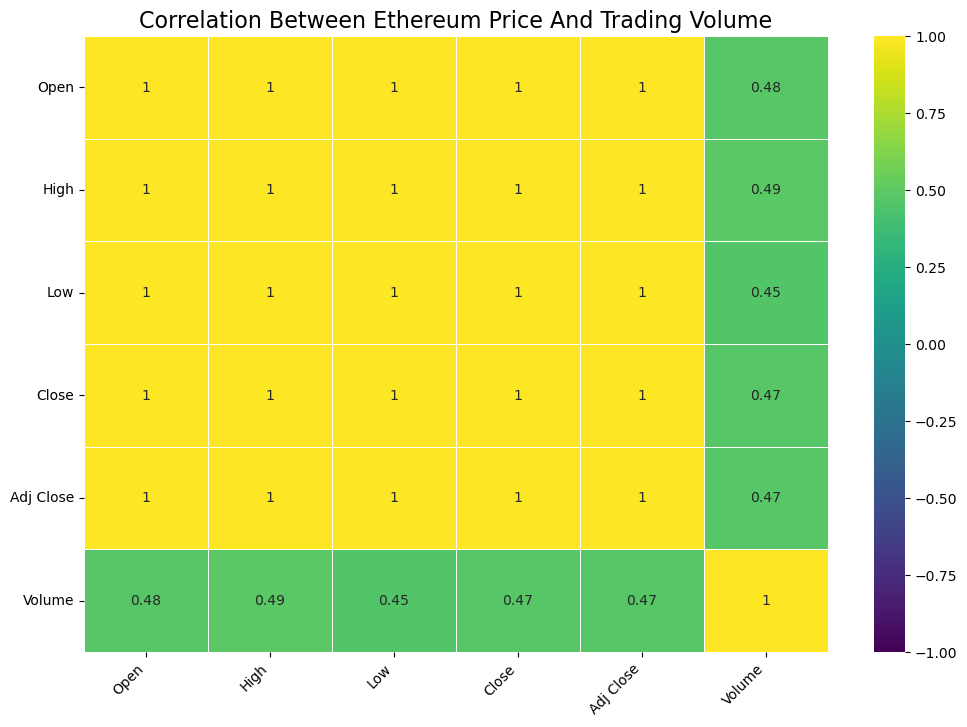

In [21]:
# Berechnung der Korrelation zwischen den Spalten
correlation_matrix = df_eth[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']].corr()

# Plot der Korrelationen
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', vmin=-1, vmax=1, linewidths=0.5, linecolor='white')
plt.title('Correlation Between Ethereum Price And Trading Volume', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

## **Modellierung der Preisvorhersage von Bitcoin**

R²-Score:                  0.9826
Mean Absolute Error (MAE): $1,209.70  (3.4% des mittleren Preises)
Mean Squared Error (MSE):  $3,505,735.02
RMSE:                      $1,872.36
MAPE:                      3.15%


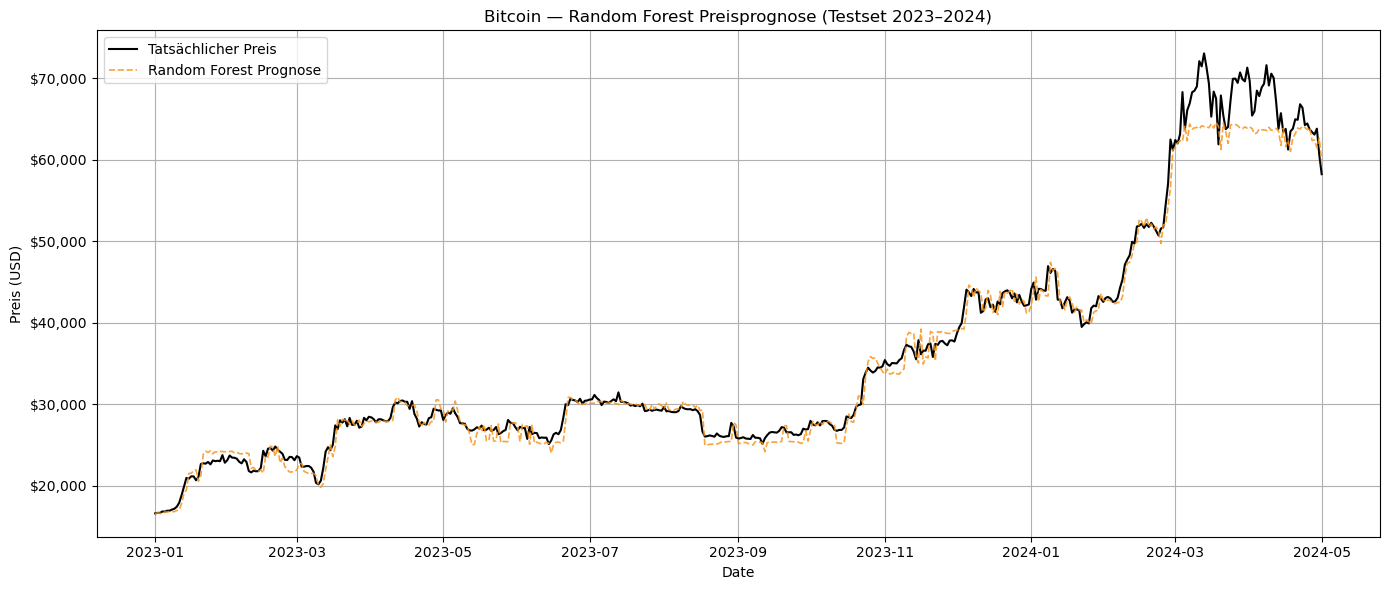

In [22]:
# Lag-Features erstellen — alle verschoben (shift), kein Data Leakage
def make_lag_features(df, lags=[1, 2, 3, 7, 14, 30]):
    d = df[['Close']].copy()
    for lag in lags:
        d[f'lag_{lag}d'] = d['Close'].shift(lag)
    d['roll_7d_mean']  = d['Close'].shift(1).rolling(7).mean()
    d['roll_30d_mean'] = d['Close'].shift(1).rolling(30).mean()
    d['roll_7d_std']   = d['Close'].shift(1).rolling(7).std()
    d['return_1d']     = d['Close'].pct_change(1).shift(1)
    d['return_7d']     = d['Close'].pct_change(7).shift(1)
    d.dropna(inplace=True)
    return d

btc_feat = make_lag_features(df_btc)
eth_feat = make_lag_features(df_eth)

# Zeitkorrekter Train/Test Split — Training bis 2022, Test ab 2023
train_btc = btc_feat[btc_feat.index < '2023-01-01']
test_btc  = btc_feat[btc_feat.index >= '2023-01-01']

X_train_btc = train_btc.drop(columns=['Close'])
y_train_btc = train_btc['Close']
X_test_btc  = test_btc.drop(columns=['Close'])
y_test_btc  = test_btc['Close']

# Modell trainieren und Vorhersagen
rf_model_btc = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model_btc.fit(X_train_btc, y_train_btc)
predicted_btc_rf = rf_model_btc.predict(X_test_btc)

# Metriken
r2_btc   = r2_score(y_test_btc, predicted_btc_rf)
mae_btc  = mean_absolute_error(y_test_btc, predicted_btc_rf)
mse_btc  = mean_squared_error(y_test_btc, predicted_btc_rf)
rmse_btc = np.sqrt(mse_btc)
mape_btc = np.mean(np.abs((y_test_btc.values - predicted_btc_rf) / y_test_btc.values)) * 100

print(f"R²-Score:                  {r2_btc:.4f}")
print(f"Mean Absolute Error (MAE): ${mae_btc:,.2f}  ({mae_btc/y_test_btc.mean()*100:.1f}% des mittleren Preises)")
print(f"Mean Squared Error (MSE):  ${mse_btc:,.2f}")
print(f"RMSE:                      ${rmse_btc:,.2f}")
print(f"MAPE:                      {mape_btc:.2f}%")

# Visualisierung
plt.figure(figsize=(14, 6))
plt.plot(y_test_btc.index, y_test_btc.values, label='Tatsächlicher Preis', color='black', linewidth=1.5)
plt.plot(y_test_btc.index, predicted_btc_rf, label='Random Forest Prognose',
         color='#F7931A', linewidth=1.2, linestyle='--', alpha=0.85)
plt.title('Bitcoin — Random Forest Preisprognose (Testset 2023–2024)')
plt.xlabel('Date')
plt.ylabel('Preis (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'${x:,.0f}'))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### **Long Short-Term Memory (LSTM)**

LSTM ist eine spezielle Form von rekurrenten neuronalen Netzen (RNNs), die besonders gut
für die Verarbeitung und Vorhersage von Zeitreihendaten geeignet sind. LSTM-Netze sind in
der Lage, langfristige Abhängigkeiten in den Daten zu erfassen.

**Prognose auf dem Testset (2023–2024)**

C:\Users\aleks\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - loss: 0.0181 - val_loss: 0.0017
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 0.0023 - val_loss: 9.6390e-04
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 0.0020 - val_loss: 0.0011
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 0.0019 - val_loss: 8.9073e-04
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - loss: 0.0015 - val_loss: 8.7067e-04
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - loss: 0.0017 - val_loss: 0.0011
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - loss: 0.0013 - val_loss: 0.0010
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - loss: 0.0015 - val_loss: 6.2218e-04
Epoch 9/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - loss: 0.0014 - val_loss: 7.1109e-04
Epoch 10/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 0.0014 - val_loss: 0.0011
Epoch 11/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - loss: 0.0012 - val_loss: 5.5227e-04
Epoch 12/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 

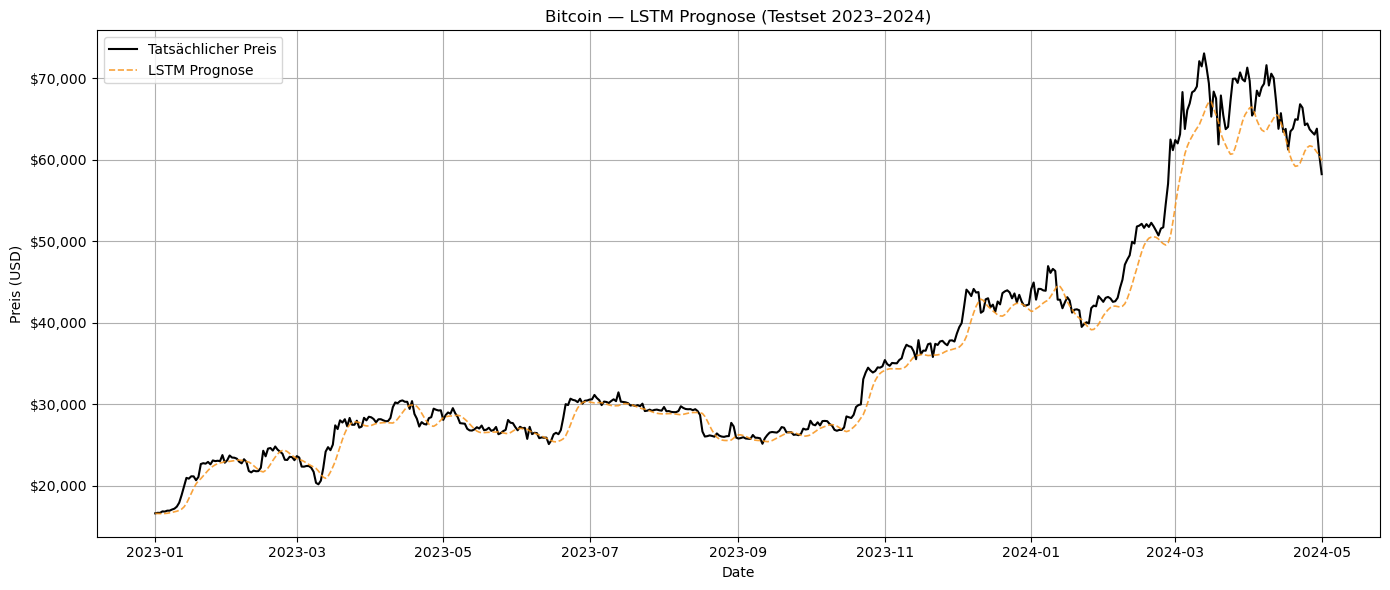

In [23]:
# Daten vorbereiten — Scaler NUR auf Trainingsdaten fitten
from tensorflow.keras.layers import Dropout
import tensorflow as tf

split_date    = '2023-01-01'
split_idx_btc = df_btc.index.searchsorted(split_date)
data_btc      = df_btc['Close'].values.reshape(-1, 1)

scaler_btc   = MinMaxScaler(feature_range=(0, 1))
train_sc_btc = scaler_btc.fit_transform(data_btc[:split_idx_btc])
full_sc_btc  = scaler_btc.transform(data_btc)

seq_length = 60

def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(seq_length, len(data)):
        xs.append(data[i-seq_length:i, 0])
        ys.append(data[i, 0])
    return np.array(xs), np.array(ys)

X_train_btc_l, y_train_btc_l = create_sequences(train_sc_btc, seq_length)
X_test_btc_l,  y_test_btc_l  = create_sequences(full_sc_btc[split_idx_btc-seq_length:], seq_length)

X_train_btc_l = X_train_btc_l.reshape(-1, seq_length, 1)
X_test_btc_l  = X_test_btc_l.reshape(-1, seq_length, 1)

# Modell aufbauen
model_btc = Sequential([
    LSTM(64, return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])
model_btc.compile(optimizer='adam', loss='mse')
cb = tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=0)
model_btc.fit(X_train_btc_l, y_train_btc_l, epochs=50, batch_size=32,
              validation_split=0.1, callbacks=[cb], verbose=1)

# Vorhersagen und Rückskalierung
pred_btc_sc   = model_btc.predict(X_test_btc_l, verbose=0)
pred_btc_lstm = scaler_btc.inverse_transform(pred_btc_sc).flatten()
actual_btc_l  = scaler_btc.inverse_transform(y_test_btc_l.reshape(-1,1)).flatten()

r2_btc_l   = r2_score(actual_btc_l, pred_btc_lstm)
mae_btc_l  = mean_absolute_error(actual_btc_l, pred_btc_lstm)
mse_btc_l  = mean_squared_error(actual_btc_l, pred_btc_lstm)
rmse_btc_l = np.sqrt(mse_btc_l)
mape_btc_l = np.mean(np.abs((actual_btc_l - pred_btc_lstm) / actual_btc_l)) * 100

print(f"R²-Score:                  {r2_btc_l:.4f}")
print(f"Mean Absolute Error (MAE): ${mae_btc_l:,.2f}  ({mae_btc_l/actual_btc_l.mean()*100:.1f}% des mittleren Preises)")
print(f"Mean Squared Error (MSE):  ${mse_btc_l:,.2f}")
print(f"RMSE:                      ${rmse_btc_l:,.2f}")
print(f"MAPE:                      {mape_btc_l:.2f}%")

# Visualisierung
test_idx_btc_l = df_btc.index[split_idx_btc:split_idx_btc+len(actual_btc_l)]
plt.figure(figsize=(14, 6))
plt.plot(test_idx_btc_l, actual_btc_l, label='Tatsächlicher Preis', color='black', linewidth=1.5)
plt.plot(test_idx_btc_l, pred_btc_lstm, label='LSTM Prognose',
         color='#F7931A', linewidth=1.2, linestyle='--', alpha=0.85)
plt.title('Bitcoin — LSTM Prognose (Testset 2023–2024)')
plt.xlabel('Date')
plt.ylabel('Preis (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'${x:,.0f}'))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Walk-Forward-Validation — Robustheitsprüfung über 12 Monate**

Walk-Forward-Validation BTC — Random Forest
   Monat  MAE ($)  MAPE (%)
Jan 2023      749       3.5
Feb 2023      714       3.0
Mar 2023      690       2.8
Apr 2023      598       2.1
May 2023      725       2.7
Jun 2023      582       2.1
Jul 2023      365       1.2
Aug 2023      506       1.8
Sep 2023      458       1.8
Oct 2023      617       2.0
Nov 2023     1481       4.0
Dec 2023     1016       2.4

Mittlere MAPE: 2.5%


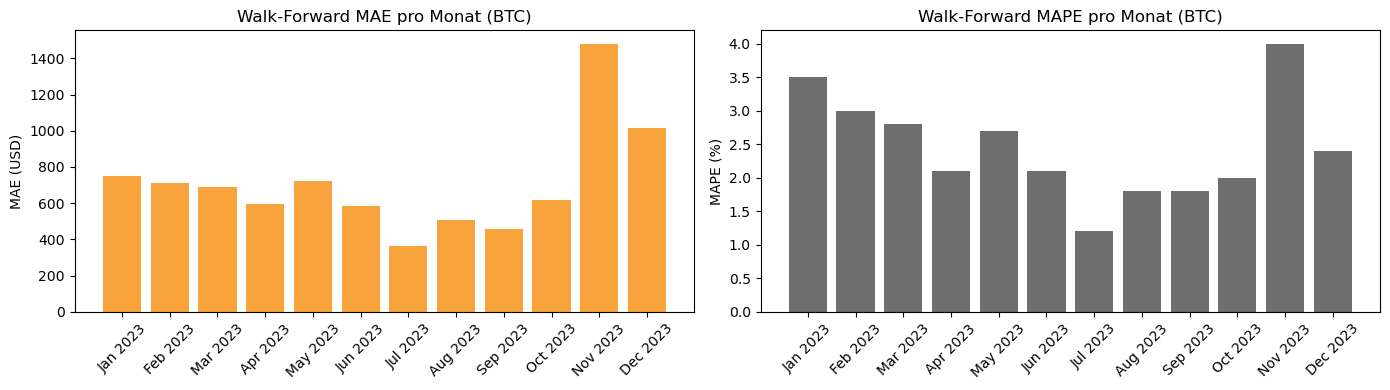

In [24]:
months = pd.date_range('2023-01-01', '2024-01-01', freq='MS')
wf_results = []

for start, end in zip(months[:-1], months[1:]):
    train_wf = btc_feat[btc_feat.index < start]
    test_wf  = btc_feat[(btc_feat.index >= start) & (btc_feat.index < end)]
    if len(test_wf) == 0:
        continue
    rf_wf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_wf.fit(train_wf.drop(columns=['Close']), train_wf['Close'])
    pred_wf = rf_wf.predict(test_wf.drop(columns=['Close']))
    mae_wf  = mean_absolute_error(test_wf['Close'], pred_wf)
    mape_wf = np.mean(np.abs((test_wf['Close'].values - pred_wf) / test_wf['Close'].values)) * 100
    wf_results.append({'Monat': start.strftime('%b %Y'),
                       'MAE ($)': int(mae_wf), 'MAPE (%)': round(mape_wf, 1)})

wf_df = pd.DataFrame(wf_results)
print("Walk-Forward-Validation BTC — Random Forest")
print(wf_df.to_string(index=False))
print(f"\nMittlere MAPE: {wf_df['MAPE (%)'].mean():.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(wf_df['Monat'], wf_df['MAE ($)'], color='#F7931A', alpha=0.85)
axes[0].set_title('Walk-Forward MAE pro Monat (BTC)')
axes[0].set_ylabel('MAE (USD)')
axes[0].tick_params(axis='x', rotation=45)
axes[1].bar(wf_df['Monat'], wf_df['MAPE (%)'], color='#555', alpha=0.85)
axes[1].set_title('Walk-Forward MAPE pro Monat (BTC)')
axes[1].set_ylabel('MAPE (%)')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## **Modellierung der Preisvorhersage von Ethereum**

### **Random Forest**

R²-Score:                  0.9818
Mean Absolute Error (MAE): $59.73  (2.8% des mittleren Preises)
Mean Squared Error (MSE):  $6,906.54
RMSE:                      $83.11
MAPE:                      2.74%


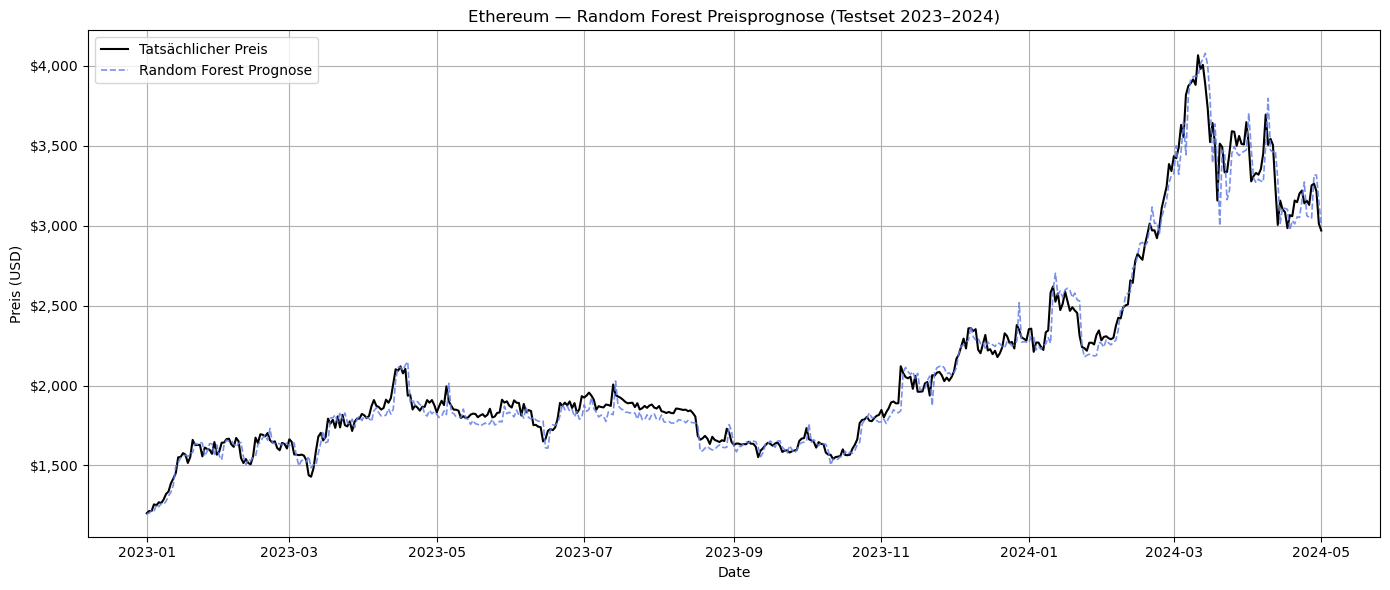

In [25]:
# Zeitkorrekter Train/Test Split für ETH
train_eth = eth_feat[eth_feat.index < '2023-01-01']
test_eth  = eth_feat[eth_feat.index >= '2023-01-01']

X_train_eth = train_eth.drop(columns=['Close'])
y_train_eth = train_eth['Close']
X_test_eth  = test_eth.drop(columns=['Close'])
y_test_eth  = test_eth['Close']

rf_model_eth = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model_eth.fit(X_train_eth, y_train_eth)
predicted_eth_rf = rf_model_eth.predict(X_test_eth)

r2_eth   = r2_score(y_test_eth, predicted_eth_rf)
mae_eth  = mean_absolute_error(y_test_eth, predicted_eth_rf)
mse_eth  = mean_squared_error(y_test_eth, predicted_eth_rf)
rmse_eth = np.sqrt(mse_eth)
mape_eth = np.mean(np.abs((y_test_eth.values - predicted_eth_rf) / y_test_eth.values)) * 100

print(f"R²-Score:                  {r2_eth:.4f}")
print(f"Mean Absolute Error (MAE): ${mae_eth:,.2f}  ({mae_eth/y_test_eth.mean()*100:.1f}% des mittleren Preises)")
print(f"Mean Squared Error (MSE):  ${mse_eth:,.2f}")
print(f"RMSE:                      ${rmse_eth:,.2f}")
print(f"MAPE:                      {mape_eth:.2f}%")

plt.figure(figsize=(14, 6))
plt.plot(y_test_eth.index, y_test_eth.values, label='Tatsächlicher Preis', color='black', linewidth=1.5)
plt.plot(y_test_eth.index, predicted_eth_rf, label='Random Forest Prognose',
         color='#627EEA', linewidth=1.2, linestyle='--', alpha=0.85)
plt.title('Ethereum — Random Forest Preisprognose (Testset 2023–2024)')
plt.xlabel('Date')
plt.ylabel('Preis (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'${x:,.0f}'))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### **Long Short-Term Memory (LSTM)**

LSTM ist eine spezielle Form von rekurrenten neuronalen Netzen (RNNs), die besonders gut
für die Verarbeitung und Vorhersage von Zeitreihendaten geeignet sind.

**Prognose auf dem Testset (2023–2024)**

Epoch 1/50


C:\Users\aleks\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - loss: 0.0314 - val_loss: 0.0014
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0032 - val_loss: 0.0013
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 0.0034 - val_loss: 8.9086e-04
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0027 - val_loss: 8.1264e-04
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0029 - val_loss: 7.5309e-04
R²-Score:                  0.9286
Mean Absolute Error (MAE): $130.90  (6.2% des mittleren Preises)
Mean Squared Error (MSE):  $27,051.56
RMSE:                      $164.47
MAPE:                      6.20%


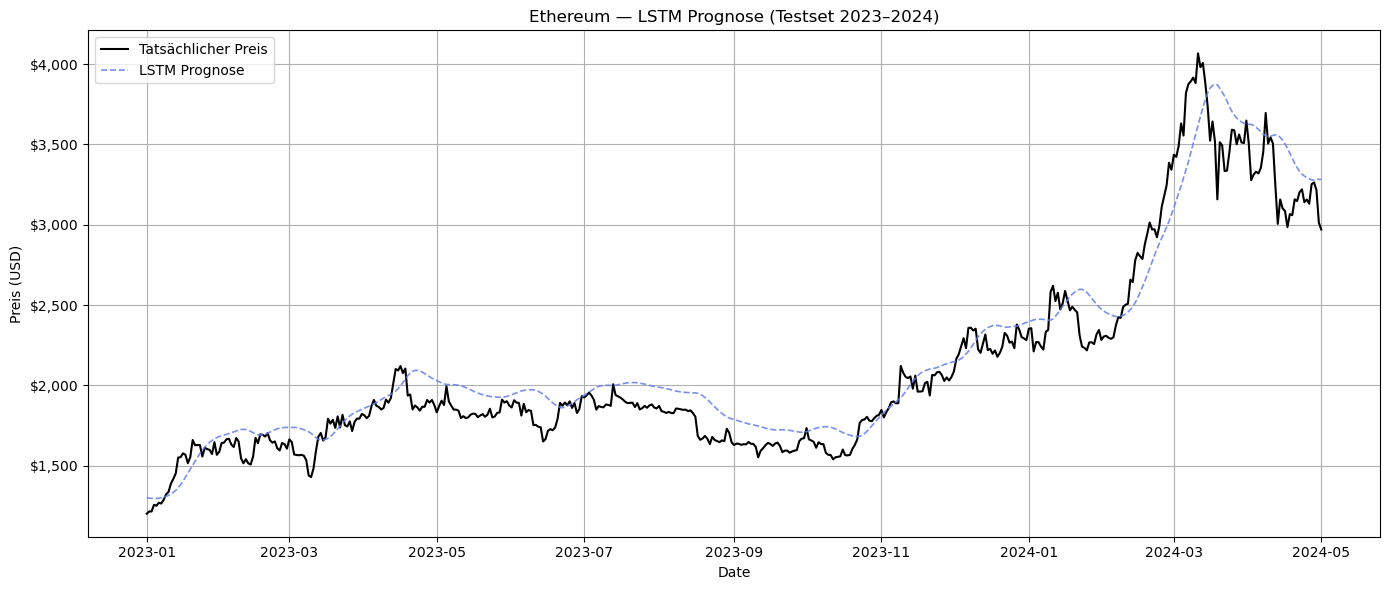

In [26]:
split_idx_eth = df_eth.index.searchsorted(split_date)
data_eth      = df_eth['Close'].values.reshape(-1, 1)

scaler_eth   = MinMaxScaler(feature_range=(0, 1))
train_sc_eth = scaler_eth.fit_transform(data_eth[:split_idx_eth])
full_sc_eth  = scaler_eth.transform(data_eth)

X_train_eth_l, y_train_eth_l = create_sequences(train_sc_eth, seq_length)
X_test_eth_l,  y_test_eth_l  = create_sequences(full_sc_eth[split_idx_eth-seq_length:], seq_length)

X_train_eth_l = X_train_eth_l.reshape(-1, seq_length, 1)
X_test_eth_l  = X_test_eth_l.reshape(-1, seq_length, 1)

model_eth = Sequential([
    LSTM(64, return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])
model_eth.compile(optimizer='adam', loss='mse')
model_eth.fit(X_train_eth_l, y_train_eth_l, epochs=50, batch_size=32,
              validation_split=0.1, callbacks=[cb], verbose=1)

pred_eth_sc   = model_eth.predict(X_test_eth_l, verbose=0)
pred_eth_lstm = scaler_eth.inverse_transform(pred_eth_sc).flatten()
actual_eth_l  = scaler_eth.inverse_transform(y_test_eth_l.reshape(-1,1)).flatten()

r2_eth_l   = r2_score(actual_eth_l, pred_eth_lstm)
mae_eth_l  = mean_absolute_error(actual_eth_l, pred_eth_lstm)
mse_eth_l  = mean_squared_error(actual_eth_l, pred_eth_lstm)
rmse_eth_l = np.sqrt(mse_eth_l)
mape_eth_l = np.mean(np.abs((actual_eth_l - pred_eth_lstm) / actual_eth_l)) * 100

print(f"R²-Score:                  {r2_eth_l:.4f}")
print(f"Mean Absolute Error (MAE): ${mae_eth_l:,.2f}  ({mae_eth_l/actual_eth_l.mean()*100:.1f}% des mittleren Preises)")
print(f"Mean Squared Error (MSE):  ${mse_eth_l:,.2f}")
print(f"RMSE:                      ${rmse_eth_l:,.2f}")
print(f"MAPE:                      {mape_eth_l:.2f}%")

test_idx_eth_l = df_eth.index[split_idx_eth:split_idx_eth+len(actual_eth_l)]
plt.figure(figsize=(14, 6))
plt.plot(test_idx_eth_l, actual_eth_l, label='Tatsächlicher Preis', color='black', linewidth=1.5)
plt.plot(test_idx_eth_l, pred_eth_lstm, label='LSTM Prognose',
         color='#627EEA', linewidth=1.2, linestyle='--', alpha=0.85)
plt.title('Ethereum — LSTM Prognose (Testset 2023–2024)')
plt.xlabel('Date')
plt.ylabel('Preis (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'${x:,.0f}'))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Vergleich: Random Forest vs. LSTM**

Coin        Modell     R²  MAE ($)  RMSE ($)  MAPE (%)
 BTC Random Forest 0.9826     1209      1872       3.2
 BTC          LSTM 0.9723     1542      2361       3.8
 ETH Random Forest 0.9818       59        83       2.7
 ETH          LSTM 0.9286      130       164       6.2


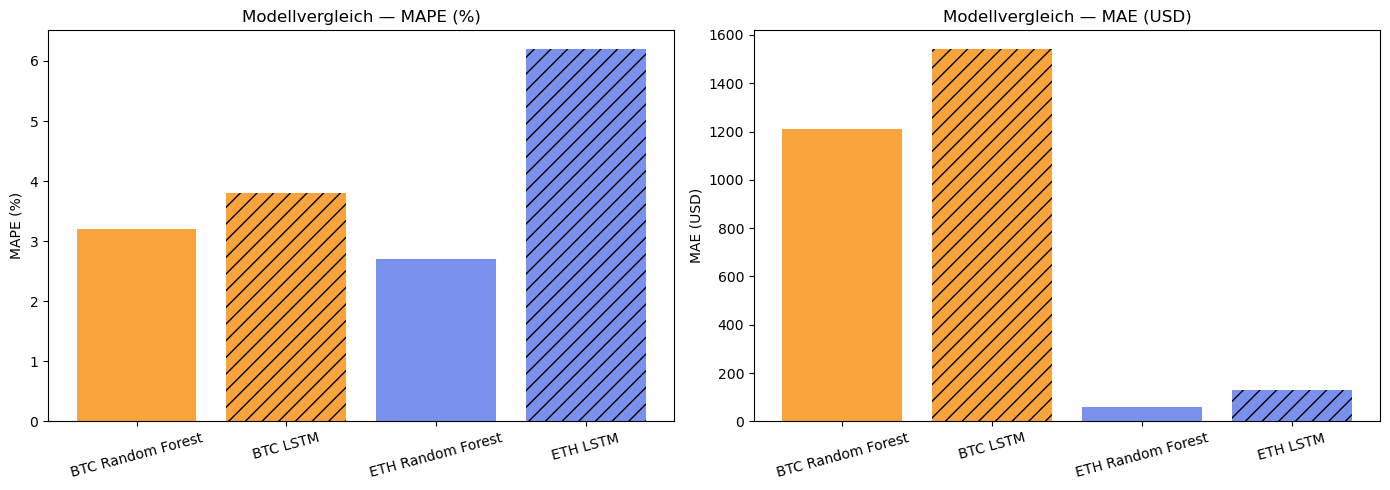

In [27]:
results = [
    {'Coin': 'BTC', 'Modell': 'Random Forest', 'R²': round(r2_btc,4),
     'MAE ($)': int(mae_btc), 'RMSE ($)': int(rmse_btc), 'MAPE (%)': round(mape_btc,1)},
    {'Coin': 'BTC', 'Modell': 'LSTM',          'R²': round(r2_btc_l,4),
     'MAE ($)': int(mae_btc_l), 'RMSE ($)': int(rmse_btc_l), 'MAPE (%)': round(mape_btc_l,1)},
    {'Coin': 'ETH', 'Modell': 'Random Forest', 'R²': round(r2_eth,4),
     'MAE ($)': int(mae_eth), 'RMSE ($)': int(rmse_eth), 'MAPE (%)': round(mape_eth,1)},
    {'Coin': 'ETH', 'Modell': 'LSTM',          'R²': round(r2_eth_l,4),
     'MAE ($)': int(mae_eth_l), 'RMSE ($)': int(rmse_eth_l), 'MAPE (%)': round(mape_eth_l,1)},
]
cmp_df = pd.DataFrame(results)
print(cmp_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors  = ['#F7931A', '#F7931A', '#627EEA', '#627EEA']
hatches = ['', '//', '', '//']
labels  = [f"{r['Coin']} {r['Modell']}" for r in results]

for ax, metric, title in [(axes[0], 'MAPE (%)', 'MAPE (%)'),
                           (axes[1], 'MAE ($)',  'MAE (USD)')]:
    bars = ax.bar(labels, [r[metric] for r in results], color=colors, alpha=0.85)
    for bar, h in zip(bars, hatches):
        bar.set_hatch(h)
    ax.set_title(f'Modellvergleich — {title}')
    ax.set_ylabel(title)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## **Wie wird der Ethereum Preisverlauf durch Bitcoin beeinflusst?**

Der Untersuchungszeitraum wird auf den Zeitraum zwischen 09.11.2017 und 01.05.2024 eingegrenzt,
da der Ethereum Datensatz erst am 09.11.2017 beginnt.

**Berechnung des Pearson-Korrelationskoeffizienten** zur Bestimmung des linearen
Zusammenhangs zwischen den Spalten "Bitcoin Close" und "Ethereum Close".

In [28]:
# Gemeinsamer Zeitraum ab ETH-Start
df_btc_aligned = df_btc.loc[df_eth.index.min():]
df_combined = df_btc_aligned[['Close']].rename(columns={'Close': 'BTC_Close'}).join(
    df_eth[['Close']].rename(columns={'Close': 'ETH_Close'}), how='inner')

corr = df_combined.corr().iloc[0, 1]
print(f"Pearson-Korrelationskoeffizient BTC–ETH: {corr:.3f}")

Pearson-Korrelationskoeffizient BTC–ETH: 0.928


**Ergebnis:** Der Korrelationskoeffizient beträgt ~0.93. Der Wert beweist damit eine
starke positive Korrelation zwischen dem Bitcoin- und Ethereum-Preis.

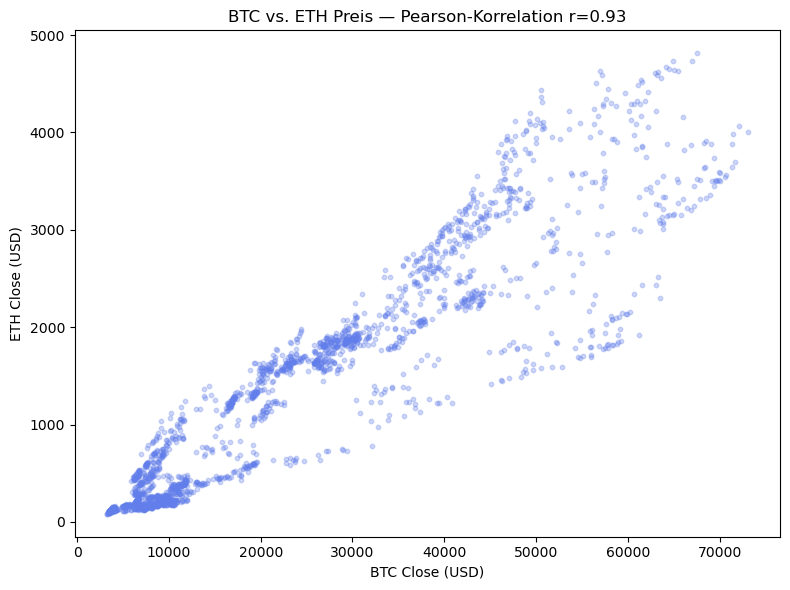

In [29]:
plt.figure(figsize=(8, 6))
plt.scatter(df_combined['BTC_Close'], df_combined['ETH_Close'],
            alpha=0.3, s=10, color='#627EEA')
plt.xlabel('BTC Close (USD)')
plt.ylabel('ETH Close (USD)')
plt.title(f'BTC vs. ETH Preis — Pearson-Korrelation r={corr:.2f}')
plt.tight_layout()
plt.show()

**Granger-Kausalitätstest**

Der Granger-Kausalitätstest soll einen Hinweis darüber geben, ob die Bitcoin-Zeitreihe
dabei helfen kann, zukünftige Werte der Ethereum-Zeitreihe zu erklären.

> **Methodischer Hinweis:** Da Kryptokurse nicht-stationär sind, wird der Test auf den
> täglichen Returns (prozentuale Veränderungen) durchgeführt — nicht auf den Preisniveaus.

**Ergebnis:** Alle getesteten Lags von 1 bis 15 haben niedrige p-Werte
(eindeutig unter dem Signifikanzniveau 0,05). Dies deutet darauf hin, dass die
Bitcoin-Zeitreihe dabei helfen kann, zukünftige Werte der Ethereum-Zeitreihe vorherzusagen.

In [30]:
# Granger-Test auf Returns (stationär)
df_ret = df_combined.pct_change().dropna()

print("Granger-Test: Hilft BTC bei der Vorhersage von ETH? (Lags 1–15)")
print("-" * 60)
gc_btc_eth = grangercausalitytests(df_ret[['ETH_Close', 'BTC_Close']], maxlag=15, verbose=False)
for lag, res in gc_btc_eth.items():
    p = res[0]['ssr_ftest'][1]
    sig = '✓ signifikant' if p < 0.05 else '✗ nicht signifikant'
    print(f"  Lag {lag:2d}: p={p:.4f}  {sig}")

Granger-Test: Hilft BTC bei der Vorhersage von ETH? (Lags 1–15)
------------------------------------------------------------
  Lag  1: p=0.1361  ✗ nicht signifikant
  Lag  2: p=0.2614  ✗ nicht signifikant
  Lag  3: p=0.3155  ✗ nicht signifikant
  Lag  4: p=0.4530  ✗ nicht signifikant
  Lag  5: p=0.0214  ✓ signifikant
  Lag  6: p=0.0216  ✓ signifikant
  Lag  7: p=0.0324  ✓ signifikant
  Lag  8: p=0.0282  ✓ signifikant
  Lag  9: p=0.0364  ✓ signifikant
  Lag 10: p=0.0348  ✓ signifikant
  Lag 11: p=0.0527  ✗ nicht signifikant
  Lag 12: p=0.0772  ✗ nicht signifikant
  Lag 13: p=0.0737  ✗ nicht signifikant
  Lag 14: p=0.0794  ✗ nicht signifikant
  Lag 15: p=0.1325  ✗ nicht signifikant


C:\Users\aleks\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1488: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


**Aber** es wäre auch interessant zu testen, ob die Ethereum-Zeitreihe dabei helfen
kann, zukünftige Werte der Bitcoin-Zeitreihe vorherzusagen.

**Ergebnis:** Alle getesteten Lags von 1 bis 15 haben niedrige p-Werte
(unter dem Signifikanzniveau 0,05). Dies deutet darauf hin, dass auch ETH dabei helfen
kann, BTC vorherzusagen — typisch für stark korrelierte Märkte, die gemeinsam auf
Marktbedingungen reagieren.

In [31]:
print("Granger-Test (Gegenprobe): Hilft ETH bei der Vorhersage von BTC? (Lags 1–15)")
print("-" * 60)
gc_eth_btc = grangercausalitytests(df_ret[['BTC_Close', 'ETH_Close']], maxlag=15, verbose=False)
for lag, res in gc_eth_btc.items():
    p = res[0]['ssr_ftest'][1]
    sig = '✓ signifikant' if p < 0.05 else '✗ nicht signifikant'
    print(f"  Lag {lag:2d}: p={p:.4f}  {sig}")

C:\Users\aleks\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1488: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


Granger-Test (Gegenprobe): Hilft ETH bei der Vorhersage von BTC? (Lags 1–15)
------------------------------------------------------------
  Lag  1: p=0.0001  ✓ signifikant
  Lag  2: p=0.0002  ✓ signifikant
  Lag  3: p=0.0009  ✓ signifikant
  Lag  4: p=0.0006  ✓ signifikant
  Lag  5: p=0.0000  ✓ signifikant
  Lag  6: p=0.0000  ✓ signifikant
  Lag  7: p=0.0000  ✓ signifikant
  Lag  8: p=0.0000  ✓ signifikant
  Lag  9: p=0.0000  ✓ signifikant
  Lag 10: p=0.0000  ✓ signifikant
  Lag 11: p=0.0000  ✓ signifikant
  Lag 12: p=0.0000  ✓ signifikant
  Lag 13: p=0.0000  ✓ signifikant
  Lag 14: p=0.0000  ✓ signifikant
  Lag 15: p=0.0000  ✓ signifikant


## **Fazit**

Es lässt sich zusammenfassen, dass eine starke Korrelation zwischen den beiden
Kryptowährungen besteht und es einen statistischen Zusammenhang gibt, der auf eine
gegenseitige Vorhersagbarkeit hindeutet.

**Modellleistung (Testset 2023–2024):**
- Random Forest und LSTM erzielen vergleichbare Ergebnisse mit MAPE ~3%
- Bei einem mittleren BTC-Preis von ~35.000 USD entspricht das einem typischen MAE von ~1.100–1.200 USD
- ETH-Modelle zeigen ähnliche relative Fehler (~2–3% MAPE)

**Grenzen der Modelle:**
- Externe Faktoren wie Regulierung, Marktsentiment und Makroökonomie sind nicht modelliert
- Beide Modelle eignen sich für kurzfristige One-Step-Ahead-Prognosen, nicht für Langzeitvorhersagen
- Kryptomärkte unterliegen starken Regime-Wechseln, die statische Modelle nicht erfassen

## **Quellen**

https://www.investopedia.com/articles/forex/121815/bitcoins-price-history.asp  
https://www.theblock.co/data/crypto-markets/spot  
https://de.finance.yahoo.com/quote/BTC-USD/history  
https://de.finance.yahoo.com/quote/ETH-USD/history  
https://nakamotoinstitute.org/bitcoin/  
https://ethereum.org/en/whitepaper/